# Collins / transversity: the $R_1 < 0.3$ cut, with and without

A copy of `plot-transversity_phicompare.ipynb`, narrowed to SBS, 2π and the
4 × 24° run on 2π's bins, with one question added: **what does the collinearity cut $R_1 < 0.3$ cost?**
Each entry is drawn in one panel with its cut twin, which is the same run fitted with
`-t 0.3` and so keeps only the simulated rows with $R_1 < 0.3$. $R_1$ is the
current-fragmentation criterion of arXiv:1611.10329 (`tmd.CalculateRfactor`;
see `physics.md`).

| key | run directory | acceptance | binning | rows, no cut | rows, $R_1<0.3$ | counts |
|---|---|---|---|---|---|---|
| `world` | `../data_world` | world data, **the reference, never cut** | — | 146 | 146 | — |
| `sbs` | `../data_sbs` | SBS projection, **stat-only panel** | — | 455 | 320 | 1x |
| `phifull` | `data_phifull` | full 2π | own | 1660 | 928 | 1x |
| `phi4seg_fullbin_x4` | `data_phi4seg24deg_phifullbin` | 4 × 24°, both arms | reused from `phifull` | 1660 | 859 | 4x |

The cut twins carry the key suffix `_r1`. Row counts are the ones the fits
printed (`runlog.md`, 2026-09-02 and 2026-09-08).

**The world data is never cut.** The filter sits inside `fitsim()`, and
`fitworld()` does not call it. So `world` is the same fit in every panel, and a
ratio to world measures the SoLID side alone.

**Luminosity is the same on both sides of each pair.** The 4x φ-cut runs are
compared with their 4x cut twins (`_r1lt0.3_x4counts`), and 2π and SBS with
their 1x twins. So the cut/no-cut ratio isolates the cut. It is **not** the same
across configurations, so compare the cut *penalty* between them, never the
raw bands.

**Why 2π bins for the φ cut.** `phi4seg_fullbin_x4` shares `phifull`'s 1660
bins, so the two lose the same bins to the cut (928 and 859 of 1660 survive)
and their penalties compare like for like.

**Standing caveat (`runlog.md`, 2026-09-02).** Every uncut fit already has
χ²/ndof < 1, and the cut pushes it further down rather than towards 1. If the
rows it discards were the ones the TMD model fits badly, χ²/ndof should have
risen. Why it falls is unresolved, so read the cut's effect on the *errors*
here, not as evidence that the model fits the TMD region better.

Figures go to `gallery_r1lt0.3/` under the same names the base notebooks use in
`gallery/`, so a figure and its uncut counterpart differ only by directory.

In [1]:
import sys, os
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

sys.path.insert(0, os.path.abspath('..'))   # tmd.py lives at the repo root
import tmd

GALLERY = 'gallery_r1lt0.3'   # same figure names as gallery/
os.makedirs(GALLERY, exist_ok=True)

Q2  = 2.4    # the single Q2 the gT figure and the ratio tables use
# The band figures draw every entry: the first carries the error band, any others
# would be central curves showing the Q2 evolution.
# One Q2. The machinery below still loops, so adding values back is a
# one-line change; with a single entry the band is drawn and nothing else.
Q2LIST = [2.4]
tol = 7.04   # the band-scale calibration; see check.md -- it cancels in every
             # error RATIO below, so the comparisons are insensitive to it

LHAPDF 6.5.6 loading /group/solid/apps/evgen/LHAPDF/LHAPDF-6.5.6/share/LHAPDF/CJ15lo/CJ15lo_0000.dat
CJ15lo PDF set, member #0, version 2; LHAPDF ID = 12300
LHAPDF 6.5.6 loading /group/solid/apps/evgen/LHAPDF/LHAPDF-6.5.6/share/LHAPDF/DSSFFlo/DSSFFlo_0211.dat
DSSFFlo PDF set, member #211, version 1; LHAPDF ID = 90211
LHAPDF 6.5.6 loading /group/solid/apps/evgen/LHAPDF/LHAPDF-6.5.6/share/LHAPDF/DSSFFlo/DSSFFlo_0321.dat
DSSFFlo PDF set, member #321, version 1; LHAPDF ID = 90321
LHAPDF 6.5.6 loading /group/solid/apps/evgen/LHAPDF/LHAPDF-6.5.6/share/LHAPDF/NNPDFpol11_100/NNPDFpol11_100_0000.dat
NNPDFpol11_100 PDF set, member #0, version 1; LHAPDF ID = 251000


## Load fit results

Each file is the raw per-replica parameter table (50 rows x `Nu,Nd,a,b,c,kt2,chi2`).

In [2]:
OBS = 'collins'
STAT, SYST = f'out-enhanced3he_collins.dat', f'out-enhanced3hesyst_collins.dat'

# The fit scripts' filename suffixes. -t 0.3 inserts _r1lt0.3 right after the
# observable and -c 4 appends _x4counts, so a cut 4x fit is
# out-enhanced3he_collins_r1lt0.3_x4counts.dat. R1 goes in after the observable
# rather than before .dat, so it composes with X4 in either order.
X4 = lambda f: f.replace('.dat', '_x4counts.dat')
R1 = lambda f: f.replace(f'_collins', f'_collins_r1lt0.3')

REF    = 'world'
CUTSUF = '_r1'          # key suffix of a cut twin

# Three of the four entries in plot-transversity_phicompare.ipynb, at the same luminosities:
# 2pi and SBS at 1x, the phi-cut run at 4x (why: see that notebook). The own-bins
# phi-cut run is left out: it re-bins under its own acceptance, so its cut removes
# different bins from phifull's.
BASE_RUNS = {
    'world':              {'dir': '../data_world',
                           'files': {'': f'out-world_collins.dat', 'syst': f'out-world_collins.dat'},
                           'label': r'$\rm world~data$',
                           'color': 'gray'},
    'sbs':                {'dir': '../data_sbs',
                           'files': {'': f'out-sbs_collins.dat'},
                           'label': r'$\rm SBS$',
                           'color': 'saddlebrown'},
    'phifull':            {'dir': 'data_phifull',
                           'files': {'': STAT, 'syst': SYST},
                           'label': r'$\rm SoLID~full~2\pi$',
                           'color': 'black'},
    'phi4seg_fullbin_x4': {'dir': 'data_phi4seg24deg_phifullbin',
                           'files': {'': X4(STAT), 'syst': X4(SYST)},
                           'label': r'$\rm 4\times24^\circ~(2\pi~bins,~4\times~counts)$',
                           'color': 'green'},
}

# Every entry except world gets a cut twin, inserted right after it: same run
# directory, same luminosity, the -t 0.3 fit. 'cut_of' names the uncut partner.
# The world fit has no twin, because the cut never touches the world data.
RUNS = {}
for run, cfg in BASE_RUNS.items():
    RUNS[run] = cfg
    if run == REF:
        continue
    RUNS[run + CUTSUF] = dict(cfg,
                              files={k: R1(v) for k, v in cfg['files'].items()},
                              label=cfg['label'] + r'$,~R_1<0.3$',
                              cut_of=run)

# the uncut SoLID/SBS entries; each is drawn with its cut twin in its own colour
CONFIGS = [r for r, c in RUNS.items() if r != REF and 'cut_of' not in c]

# SBS has no systematics model of its own, so it has no 'syst' fit. runs_for()
# therefore leaves it (and its twin) out of every stat+syst panel.
def runs_for(suffix):
    return [(run, cfg) for run, cfg in RUNS.items() if suffix in cfg['files']]

VARIANTS = ['', 'syst']

par = {}
for run, cfg in RUNS.items():
    for suf in VARIANTS:
        if suf not in cfg['files']:
            print(f'{run+suf:26s} {"-- no fit; absent from this panel":62s}')
            continue
        path = os.path.join(cfg['dir'], cfg['files'][suf])
        par[run + suf] = pd.read_csv(path, sep=r'\s+', index_col=False)
        print(f'{run+suf:26s} {path:62s} {len(par[run+suf])} replicas')

world                      ../data_world/out-world_collins.dat                            500 replicas
worldsyst                  ../data_world/out-world_collins.dat                            500 replicas
sbs                        ../data_sbs/out-sbs_collins.dat                                500 replicas
sbssyst                    -- no fit; absent from this panel                             
sbs_r1                     ../data_sbs/out-sbs_collins_r1lt0.3.dat                        500 replicas
sbs_r1syst                 -- no fit; absent from this panel                             
phifull                    data_phifull/out-enhanced3he_collins.dat                       500 replicas
phifullsyst                data_phifull/out-enhanced3hesyst_collins.dat                   500 replicas
phifull_r1                 data_phifull/out-enhanced3he_collins_r1lt0.3.dat               500 replicas
phifull_r1syst             data_phifull/out-enhanced3hesyst_collins_r1lt0.3.dat           500 repli

phi4seg_fullbin_x4syst     data_phi4seg24deg_phifullbin/out-enhanced3hesyst_collins_x4counts.dat 500 replicas
phi4seg_fullbin_x4_r1      data_phi4seg24deg_phifullbin/out-enhanced3he_collins_r1lt0.3_x4counts.dat 500 replicas
phi4seg_fullbin_x4_r1syst  data_phi4seg24deg_phifullbin/out-enhanced3hesyst_collins_r1lt0.3_x4counts.dat 500 replicas


### Fitted parameters, run by run

Mean ± std across replicas — a first look before propagating into $h_1$.

In [3]:
rows = []
for key, p in par.items():
    r = {'run': key}
    for c in p.columns:
        r[c] = f'{p[c].mean():.4f} +- {p[c].std():.4f}'
    rows.append(r)
partable = pd.DataFrame(rows).set_index('run')
partable

,Nu,Nd,a,b,c,kt2,Nu_err,Nd_err,a_err,b_err,c_err,kt2_err,chi2,ndof,edm
run,,,,,,,,,,,,,,,
world,0.4007 +- 0.0125,-0.4511 +- 0.0311,1.0008 +- 0.0537,3.0103 +- 0.3782,0.0000 +- 0.0000,0.2496 +- 0.0224,0.0123 +- 0.0010,0.0313 +- 0.0014,0.0558 +- 0.0010,0.3842 +- 0.0075,nan +- nan,0.0207 +- 0.0006,140.5382 +- 16.0417,141.0000 +- 0.0000,0.0000 +- 0.0000
worldsyst,0.4007 +- 0.0125,-0.4511 +- 0.0311,1.0008 +- 0.0537,3.0103 +- 0.3782,0.0000 +- 0.0000,0.2496 +- 0.0224,0.0123 +- 0.0010,0.0313 +- 0.0014,0.0558 +- 0.0010,0.3842 +- 0.0075,nan +- nan,0.0207 +- 0.0006,140.5382 +- 16.0417,141.0000 +- 0.0000,0.0000 +- 0.0000
sbs,0.5301 +- 0.3334,-0.5991 +- 0.3811,1.0265 +- 0.0842,2.9069 +- 0.2391,-0.0026 +- 0.6624,0.2506 +- 0.0097,0.0936 +- 0.1250,0.1065 +- 0.1427,0.0345 +- 0.0134,0.1432 +- 0.0814,0.1828 +- 0.1102,0.0123 +- 0.0002,450.6328 +- 30.5383,595.0000 +- 0.0000,0.0005 +- 0.0018
sbs_r1,0.5368 +- 0.3401,-0.6045 +- 0.3821,1.0282 +- 0.0795,2.9042 +- 0.2689,-0.0142 +- 0.6719,0.2508 +- 0.0100,0.0992 +- 0.1433,0.1140 +- 0.1639,0.0363 +- 0.0100,0.1611 +- 0.1018,0.2027 +- 0.1401,0.0159 +- 0.0003,315.8054 +- 25.2782,460.0000 +- 0.0000,0.0003 +- 0.0010
phifull,0.4087 +- 0.0658,-0.4597 +- 0.0737,1.0027 +- 0.0264,2.9954 +- 0.0393,-0.0006 +- 0.2103,0.2500 +- 0.0010,0.0089 +- 0.0117,0.0098 +- 0.0132,0.0083 +- 0.0034,0.0299 +- 0.0022,0.0337 +- 0.0525,0.0010 +- 0.0000,1652.8844 +- 56.9147,1800.0000 +- 0.0000,0.0018 +- 0.0088
phifullsyst,0.4369 +- 0.1528,-0.4911 +- 0.1711,1.0099 +- 0.0538,2.9775 +- 0.0848,0.0143 +- 0.4444,0.2500 +- 0.0022,0.0355 +- 0.0379,0.0395 +- 0.0426,0.0201 +- 0.0108,0.0549 +- 0.0113,0.1420 +- 0.2021,0.0023 +- 0.0000,1653.2022 +- 56.8598,1800.0000 +- 0.0000,0.0018 +- 0.0063
phifull_r1,0.4244 +- 0.1195,-0.4775 +- 0.1340,1.0064 +- 0.0438,2.9841 +- 0.0648,0.0054 +- 0.3602,0.2498 +- 0.0028,0.0231 +- 0.0254,0.0258 +- 0.0287,0.0162 +- 0.0073,0.0469 +- 0.0054,0.0939 +- 0.1386,0.0028 +- 0.0000,922.1828 +- 44.6832,1068.0000 +- 0.0000,0.0021 +- 0.0074
phifull_r1syst,0.4719 +- 0.2108,-0.5311 +- 0.2374,1.0183 +- 0.0676,2.9537 +- 0.1224,-0.0018 +- 0.5689,0.2497 +- 0.0050,0.0591 +- 0.0577,0.0662 +- 0.0649,0.0292 +- 0.0150,0.0754 +- 0.0210,0.2190 +- 0.2995,0.0051 +- 0.0001,922.6043 +- 44.6524,1068.0000 +- 0.0000,0.0028 +- 0.0252
phi4seg_fullbin_x4,0.4213 +- 0.1142,-0.4737 +- 0.1278,1.0058 +- 0.0390,2.9867 +- 0.0891,0.0051 +- 0.3309,0.2500 +- 0.0020,0.0214 +- 0.0245,0.0237 +- 0.0276,0.0176 +- 0.0063,0.0679 +- 0.0062,0.0844 +- 0.1293,0.0021 +- 0.0000,1653.3453 +- 56.7972,1800.0000 +- 0.0000,0.0019 +- 0.0071


## Calculate $xh_1(x)$

Identical to `h1calc()` in `plot-transversity_phifull.ipynb`: for each $x$, evaluate
`tmd.h1col` once per replica using that replica's own parameters, then take
central value = mean, error = `tol` × std.

In [4]:
def h1calc(pset, Q2, tol):
    rows = []
    X = np.linspace(1e-3, 1, 200)
    pset = pset.reset_index(drop=True)
    for x in X:
        xu, xd, ratio = [], [], []
        for i in range(len(pset)):
            h1 = tmd.h1col(x, Q2, 'proton', pset.loc[i])
            xu.append(x * h1[2])
            xd.append(x * h1[1])
            ratio.append(h1[1] / h1[2])
        rows.append({'x': x,
                     'xu': np.mean(xu),  'Exu': tol * np.std(xu),
                     'xd': np.mean(xd),  'Exd': tol * np.std(xd),
                     'd/u': np.mean(ratio), 'Ed/u': tol * np.std(ratio)})
    return pd.DataFrame(rows)

In [5]:
%%time
h1 = {}
for q2 in Q2LIST:
    h1[q2] = {}
    for key in par:
        h1[q2][key] = h1calc(par[key], q2, tol)
    print('done Q2 =', q2)

/tmp/ipykernel_327988/1797581884.py:11: RuntimeWarning: invalid value encountered in double_scalars
  ratio.append(h1[1] / h1[2])


done Q2 = 2.4
CPU times: user 2min 8s, sys: 46.1 ms, total: 2min 8s
Wall time: 2min 9s


## $xh_1(x)$ bands: every configuration, no cut vs $R_1 < 0.3$, in one plot

Top: world (gray) and each configuration in its own colour. **Filled band, solid
line = no cut; dashed lines = the edges of the $R_1<0.3$ band.** $u$ and $d$ are the two
lobes and are labelled on the curves. Bottom: **Error($R_1<0.3$) / Error(no cut)**
per configuration, $u$ solid and $d$ dashed. Above 1 means the cut costs
precision. `tol` cancels in it, and so does the luminosity, since both members of
a pair were fitted at the same counts.

In [6]:
def band_plot(suffix, fname, title):
    runs = [r for r in CONFIGS if suffix in RUNS[r]['files']]
    fig = plt.figure(figsize=(6.5, 10))
    q2 = Q2LIST[0]

    ax = fig.add_subplot(2, 1, 1)
    d = h1[q2][REF + suffix]
    for q in ('xu', 'xd'):
        ax.fill_between(d['x'], d[q] - d['E' + q], d[q] + d['E' + q],
                        color=RUNS[REF]['color'], alpha=0.30, linewidth=0)
        ax.plot(d['x'], d[q], color=RUNS[REF]['color'], linewidth=1.2,
                label=RUNS[REF]['label'] if q == 'xu' else None)
    for run in runs:
        color = RUNS[run]['color']
        for key, cut in ((run + CUTSUF, True), (run, False)):   # wider cut band first
            d = h1[q2][key + suffix]
            for q in ('xu', 'xd'):
                lo, hi = d[q] - d['E' + q], d[q] + d['E' + q]
                if cut:     # the cut band as its two dashed edges, so the fills stay readable
                    for edge in (lo, hi):
                        ax.plot(d['x'], edge, color=color, linestyle='--', linewidth=1.3,
                                label=RUNS[key]['label'] if (q == 'xu' and edge is lo) else None)
                else:
                    ax.fill_between(d['x'], lo, hi, color=color, alpha=0.30, linewidth=0)
                    ax.plot(d['x'], d[q], color=color, linewidth=1.2,
                            label=RUNS[key]['label'] if q == 'xu' else None)
    ax.axhline(y=0, linestyle='-', color='black', alpha=0.9, linewidth=1)
    for xv in (0.05, 0.60):
        ax.axvline(x=xv, linestyle=':', color='black', alpha=0.7, linewidth=1)
    ax.set_ylabel(r'$xh_1(x)$', size=25)
    ax.set_xlim(0, 0.7)
    ax.set_ylim(-0.45, 0.45)
    ax.set_xticklabels([])
    ax.tick_params(axis='both', which='both', direction='in', labelsize=20)
    ax.text(0.5, 0.96, title, horizontalalignment='center', verticalalignment='center',
            transform=ax.transAxes, fontsize=15)
    ax.text(0.03, 0.89, r'$Q^2 = ' + f'{q2:g}' + r'~{\rm GeV}^2$',
            transform=ax.transAxes, fontsize=13)
    # u and d labelled ON the curves, placed by the sign of each lobe
    dref = h1[q2][REF + suffix]
    j = int(np.argmin(np.abs(dref['x'].values - 0.15)))   # clear of the legend
    lo, hi = ax.get_ylim()
    pad = 0.07 * (hi - lo)
    for q, lab in (('xu', 'u'), ('xd', 'd')):
        v = dref[q].values[j]
        ax.text(0.15, v + (pad if v >= 0 else -pad), rf'${lab}$', fontsize=19,
                ha='center', va='bottom' if v >= 0 else 'top', color='black')
    ax.legend(loc='lower right', frameon=False, fontsize=9)

    ax = fig.add_subplot(2, 1, 2)
    rmax = 1.0
    for run in runs:
        d0, d1 = h1[q2][run + suffix], h1[q2][run + CUTSUF + suffix]
        inx = (d0['x'] >= 0.05) & (d0['x'] <= 0.6)
        for q, ls, lab in (('Exu', '-', 'u'), ('Exd', '--', 'd')):
            r = d1[q] / d0[q]
            rmax = max(rmax, r[inx].max())
            ax.plot(d0['x'], r, color=RUNS[run]['color'], linestyle=ls, linewidth=2.5,
                    alpha=0.8, label=RUNS[run]['label'] + rf'$~{lab}$')
    ax.axhline(y=1, linestyle='-', color='black', alpha=0.6, linewidth=1)
    for xv in (0.05, 0.60):
        ax.axvline(x=xv, linestyle=':', color='black', alpha=0.7, linewidth=1)
    ax.set_xlabel(r'$x$', size=25)
    ax.set_ylabel(r'$\rm Error^{R_1<0.3}/Error^{no~cut}$', size=20)
    ax.set_xlim(0, 0.7)
    ax.set_ylim(0, 1.25 * rmax)     # headroom for the legend
    ax.tick_params(axis='both', which='both', direction='in', labelsize=20)
    ax.legend(loc='upper right', frameon=False, fontsize=9, ncol=2)

    fig.tight_layout()
    fig.savefig(f'{GALLERY}/{fname}')
    return fig

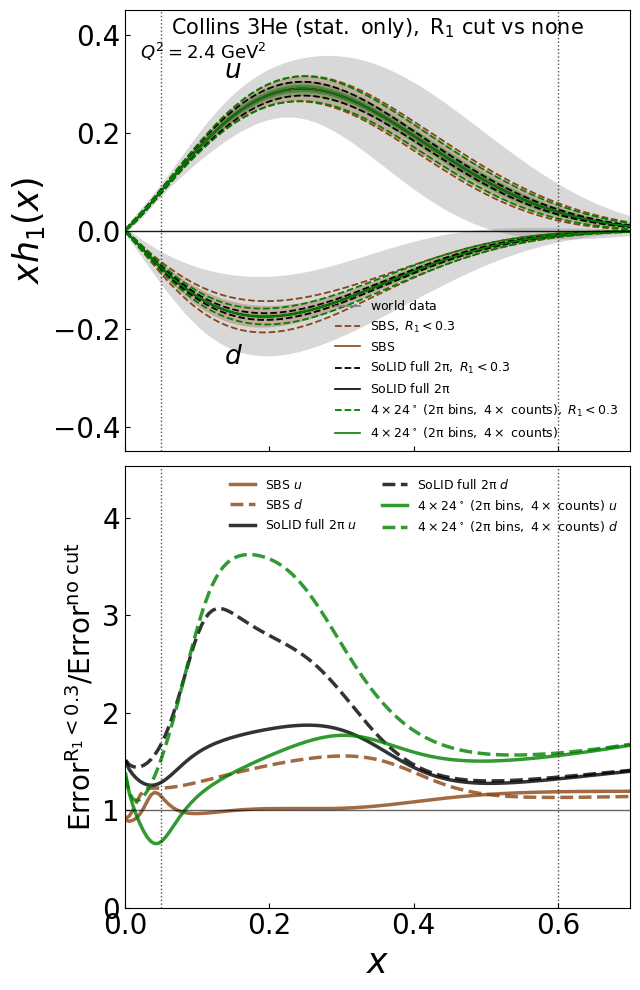

In [7]:
band_plot('', 'trans-phicompare.pdf',
          r'$\rm Collins~3He~(stat.~only),~R_1~cut~vs~none$');

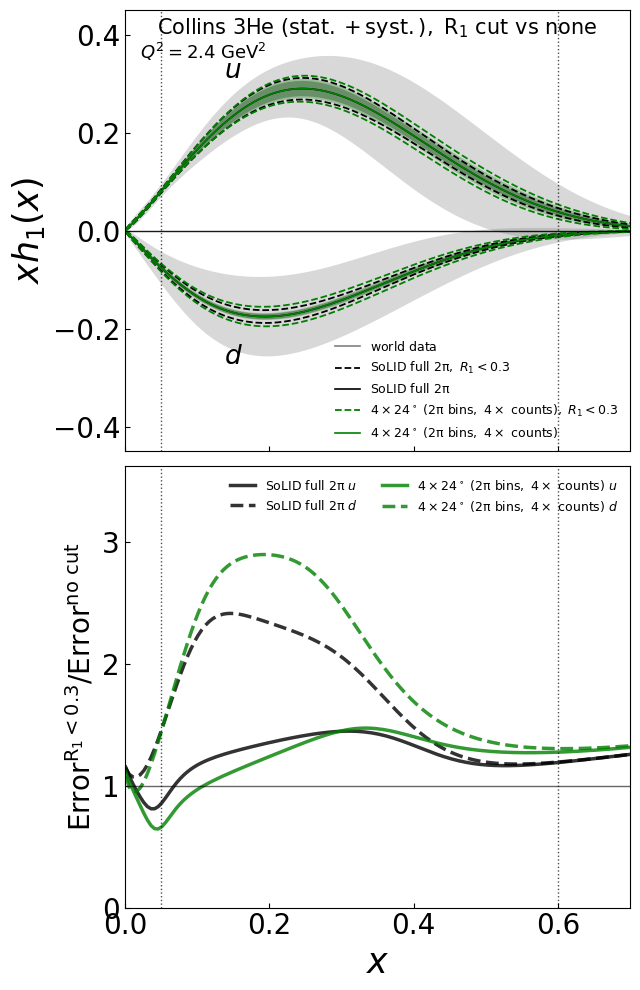

In [8]:
band_plot('syst', 'trans-phicompare-syst.pdf',
          r'$\rm Collins~3He~(stat.+syst.),~R_1~cut~vs~none$');

## Uncertainty ratios at representative $x$

First table: Error(world)/Error for every entry, cut and uncut. This is the same
table as the base notebook, with the cut twins added. Second table: the cut
penalty, Error($R_1<0.3$)/Error(no cut), which is the bottom row of the band
figures in numbers.

In [9]:
XPTS = [0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6]

rows = []
for suffix, sname in [('', 'stat'), ('syst', 'stat+syst')]:
    ref = h1[Q2LIST[0]][REF + suffix]
    for run, cfg in runs_for(suffix):
        if run == REF:
            continue
        d = h1[Q2LIST[0]][run + suffix]
        for q, lab in [('Exu', 'u'), ('Exd', 'd')]:
            r = {'variant': sname, 'run': run, 'quark': lab}
            for x in XPTS:
                j = int(np.argmin(np.abs(d['x'].values - x)))
                r[f'x={x}'] = round(ref[q].values[j] / d[q].values[j], 2)
            rows.append(r)
ratios = pd.DataFrame(rows).set_index(['variant', 'run', 'quark'])
print('Error^world / Error  (larger = SoLID better; 20 means 20x more precise)')
ratios

Error^world / Error  (larger = SoLID better; 20 means 20x more precise)


x=0.05  x=0.1  x=0.2  x=0.3  x=0.4  \
variant   run                   quark                                       
stat      sbs                   u        3.67   2.92   2.35   2.94   3.96   
                                d        3.34   3.22   3.74   5.00   6.34   
          sbs_r1                u        3.24   3.03   2.32   2.88   3.67   
                                d        2.72   2.50   2.56   3.22   4.54   
          phifull               u        4.02   6.17   7.00  11.44  15.99   
                                d       13.26  32.46  32.80  28.93  22.10   
          phifull_r1            u        3.12   3.88   3.82   6.30  11.05   
                                d        7.85  11.54  11.78  13.23  14.96   
          phi4seg_fullbin_x4    u        2.82   3.51   3.53   5.70   7.53   
                                d        7.16  15.39  17.74  13.22   9.29   
          phi4seg_fullbin_x4_r1 u        4.14   3.07   2.26   3.22   4.71   
                                d        4.64   5.32   4.97   4.94   5.08   
stat+syst phifull               u        2.96   3.53   3.44   5.65   9.51   
                                d        7.34  13.30  14.51  14.49  13.35   
          phifull_r1            u        3.44   3.01   2.53   3.91   7.11   
                                d        5.00   5.95   6.22   7.07   8.94   
          phi4seg_fullbin_x4    u        3.05   3.05   2.74   4.37   6.03   
                                d        5.80  10.21  11.71  10.17   7.58   
          phi4seg_fullbin_x4_r1 u        4.59   3.13   2.21   3.01   4.29   
                                d        3.97   4.23   4.04   4.13   4.44   

                                       x=0.5  x=0.6  
variant   run                   quark                
stat      sbs                   u       4.18   3.80  
                                d       5.50   4.30  
          sbs_r1                u       3.61   3.20  
                                d       4.72   3.81  
          phifull               u      15.78  14.58  
                                d      17.41  15.07  
          phifull_r1            u      12.38  11.06  
                                d      13.40  11.28  
          phi4seg_fullbin_x4    u       7.14   6.50  
                                d       7.38   6.47  
          phi4seg_fullbin_x4_r1 u       4.75   4.17  
                                d       4.68   4.09  
stat+syst phifull               u      10.03   8.77  
                                d      10.72   8.84  
          phifull_r1            u       8.56   7.37  
                                d       8.96   7.41  
          phi4seg_fullbin_x4    u       5.61   4.89  
                                d       5.84   4.90  
          phi4seg_fullbin_x4_r1 u       4.36   3.83  
                                d       4.26   3.75

In [10]:
rows = []
for suffix, sname in [('', 'stat'), ('syst', 'stat+syst')]:
    for run in CONFIGS:
        if suffix not in RUNS[run]['files']:
            continue
        d0 = h1[Q2LIST[0]][run + suffix]
        d1 = h1[Q2LIST[0]][run + CUTSUF + suffix]
        for q, lab in [('Exu', 'u'), ('Exd', 'd')]:
            r = {'variant': sname, 'run': run, 'quark': lab}
            for x in XPTS:
                j = int(np.argmin(np.abs(d0['x'].values - x)))
                r[f'x={x}'] = round(d1[q].values[j] / d0[q].values[j], 2)
            rows.append(r)
print('Error(R1<0.3) / Error(no cut)  (above 1 = the cut costs precision)')
pd.DataFrame(rows).set_index(['variant', 'run', 'quark'])

Error(R1<0.3) / Error(no cut)  (above 1 = the cut costs precision)


x=0.05  x=0.1  x=0.2  x=0.3  x=0.4  x=0.5  \
variant   run                quark                                              
stat      sbs                u        1.13   0.96   1.01   1.02   1.08   1.16   
                             d        1.23   1.29   1.46   1.56   1.40   1.16   
          phifull            u        1.29   1.59   1.83   1.82   1.45   1.27   
                             d        1.69   2.81   2.78   2.19   1.48   1.30   
          phi4seg_fullbin_x4 u        0.68   1.15   1.56   1.77   1.60   1.50   
                             d        1.54   2.89   3.57   2.68   1.83   1.58   
stat+syst phifull            u        0.86   1.17   1.36   1.45   1.34   1.17   
                             d        1.47   2.23   2.33   2.05   1.49   1.20   
          phi4seg_fullbin_x4 u        0.66   0.97   1.24   1.45   1.41   1.29   
                             d        1.46   2.42   2.90   2.46   1.71   1.37   

                                    x=0.6  
variant   run                quark         
stat      sbs                u       1.19  
                             d       1.13  
          phifull            u       1.32  
                             d       1.34  
          phi4seg_fullbin_x4 u       1.56  
                             d       1.58  
stat+syst phifull            u       1.19  
                             d       1.19  
          phi4seg_fullbin_x4 u       1.28  
                             d       1.30

## $-h_1^d/h_1^u$

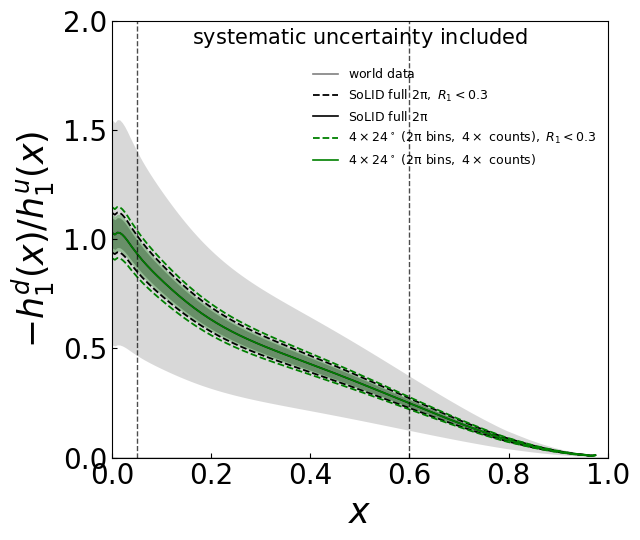

In [11]:
# One panel, as in the band figures: filled/solid = no cut, dashed edges = R1<0.3.
fig = plt.figure(figsize=(6.5, 5.5))
ax = fig.add_subplot(1, 1, 1)
d = h1[Q2LIST[0]][REF + 'syst']
ax.fill_between(d['x'], -d['d/u'] - d['Ed/u'], -d['d/u'] + d['Ed/u'],
                color=RUNS[REF]['color'], alpha=0.30, linewidth=0)
ax.plot(d['x'], -d['d/u'], color=RUNS[REF]['color'], linewidth=1.2, label=RUNS[REF]['label'])
for run in [r for r in CONFIGS if 'syst' in RUNS[r]['files']]:      # SBS has no syst fit
    color = RUNS[run]['color']
    for key, cut in ((run + CUTSUF, True), (run, False)):
        d = h1[Q2LIST[0]][key + 'syst']
        lo, hi = -d['d/u'] - d['Ed/u'], -d['d/u'] + d['Ed/u']
        if cut:     # the cut band as its two dashed edges
            for edge in (lo, hi):
                ax.plot(d['x'], edge, color=color, linestyle='--', linewidth=1.3,
                        label=RUNS[key]['label'] if edge is lo else None)
        else:
            ax.fill_between(d['x'], lo, hi, color=color, alpha=0.30, linewidth=0)
            ax.plot(d['x'], -d['d/u'], color=color, linewidth=1.2, label=RUNS[key]['label'])
ax.axhline(y=0, linestyle='-', color='black', alpha=0.9, linewidth=1)
ax.axvline(x=0.05, linestyle='--', color='black', alpha=0.7, linewidth=1)
ax.axvline(x=0.60, linestyle='--', color='black', alpha=0.7, linewidth=1)
ax.set_xlabel(r'$x$', size=25)
ax.set_ylabel(r'$-h_1^d(x)/h_1^u(x)$', size=25)
ax.set_xlim(0, 1)
ax.set_ylim(0, 2)
ax.tick_params(axis='both', which='both', direction='in', labelsize=20)
ax.text(0.5, 0.96, r'$\rm systematic~uncertainty~included$',
        horizontalalignment='center', verticalalignment='center',
        transform=ax.transAxes, fontsize=15)
ax.legend(loc='upper right', bbox_to_anchor=(1, 0.92), frameon=False, fontsize=9)
fig.tight_layout()
fig.savefig(f'{GALLERY}/trans-doveru-phicompare.pdf')

## Tensor charge $g_T$

`gtcalc` integrates over all $x$; `gttruncate` restricts to the measured range
$0.05 < x < 0.6$ — the truncated one is the honest comparison, since the full
integral extrapolates outside SoLID coverage.

`tmd.gt_fast` replaces `tmd.gt` here: fixed-node quadrature on a grid shared by
all replicas, ~780x faster and agreeing with `gt` to 4e-9 (truncated) and 4e-7
(full). `gt` remains the reference for one-off authoritative numbers.


In [12]:
def gtcalc(pset, Q2, tol, xl=None, xu=None):
    pset = pset.reset_index(drop=True)
    gu, gd, gt = [], [], []
    for i in range(len(pset)):
        tmp = tmd.gt_fast(Q2, pset.loc[i]) if xl is None else tmd.gt_fast(Q2, pset.loc[i], xl, xu)
        gu.append(tmp['u']); gd.append(tmp['d']); gt.append(tmp['u-d'])
    return {'u': np.mean(gu), 'Eu': np.std(gu) * tol,
            'd': np.mean(gd), 'Ed': np.std(gd) * tol,
            'u-d': np.mean(gt), 'Eu-d': np.std(gt) * tol}

gt  = {k: gtcalc(par[k], Q2, tol) for k in par}
gtt = {k: gtcalc(par[k], Q2, tol, 0.05, 0.6) for k in par}

In [13]:
rows = []
for k in par:
    rows.append({'run': k,
                 'gT(u)':  f"{gt[k]['u']:.4f} +- {gt[k]['Eu']:.4f}",
                 'gT(d)':  f"{gt[k]['d']:.4f} +- {gt[k]['Ed']:.4f}",
                 'gT(u-d)': f"{gt[k]['u-d']:.4f} +- {gt[k]['Eu-d']:.4f}",
                 'gT trunc (u-d)': f"{gtt[k]['u-d']:.4f} +- {gtt[k]['Eu-d']:.4f}"})
pd.DataFrame(rows).set_index('run')

,gT(u),gT(d),gT(u-d),gT trunc (u-d)
run,,,,
world,0.5475 +- 0.1175,-0.3766 +- 0.1715,0.9241 +- 0.2111,0.7654 +- 0.1701
worldsyst,0.5475 +- 0.1175,-0.3766 +- 0.1715,0.9241 +- 0.2111,0.7654 +- 0.1701
sbs,0.5462 +- 0.0409,-0.3760 +- 0.0417,0.9222 +- 0.0417,0.7656 +- 0.0395
sbs_r1,0.5462 +- 0.0425,-0.3761 +- 0.0599,0.9223 +- 0.0593,0.7658 +- 0.0522
phifull,0.5470 +- 0.0158,-0.3760 +- 0.0098,0.9230 +- 0.0200,0.7651 +- 0.0107
phifullsyst,0.5469 +- 0.0239,-0.3757 +- 0.0181,0.9225 +- 0.0274,0.7652 +- 0.0195
phifull_r1,0.5466 +- 0.0221,-0.3759 +- 0.0169,0.9225 +- 0.0298,0.7649 +- 0.0238
phifull_r1syst,0.5463 +- 0.0282,-0.3755 +- 0.0283,0.9218 +- 0.0389,0.7649 +- 0.0371
phi4seg_fullbin_x4,0.5470 +- 0.0248,-0.3759 +- 0.0183,0.9229 +- 0.0298,0.7652 +- 0.0197


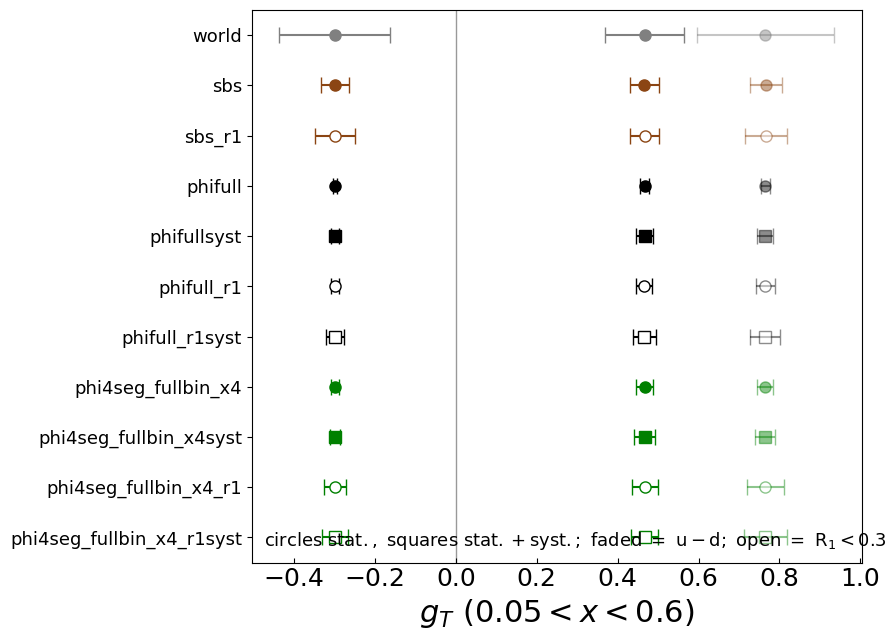

In [14]:
fig = plt.figure(figsize=(9, 6.5))
ax = fig.add_subplot(1, 1, 1)

ypos = {}
y = 0
for run, cfg in RUNS.items():
    for suffix, sname in [('', 'stat'), ('syst', 'stat+syst')]:
        if suffix not in cfg['files']:
            continue          # SBS is stat-only -- one row, in the stat block
        if run == REF and suffix == 'syst':
            continue          # world points both variants at the same fit
        key = run + suffix
        ypos[key] = y
        src = gtt[key]
        ls = 'o' if suffix == '' else 's'
        # cut twin: open marker in its partner's colour
        mfc = 'white' if 'cut_of' in cfg else cfg['color']
        ax.errorbar(src['u'],   y, xerr=src['Eu'],   marker=ls, color=cfg['color'],
                    markersize=8, capsize=6, mfc=mfc)
        ax.errorbar(src['d'],   y, xerr=src['Ed'],   marker=ls, color=cfg['color'],
                    markersize=8, capsize=6, mfc=mfc)
        ax.errorbar(src['u-d'], y, xerr=src['Eu-d'], marker=ls, color=cfg['color'],
                    markersize=8, capsize=6, mfc=mfc, alpha=0.45)
        y -= 1

ax.set_yticks(list(ypos.values()))
ax.set_yticklabels(list(ypos.keys()), fontsize=13)
ax.set_xlabel(r'$g_T~(0.05<x<0.6)$', size=22)
ax.tick_params(axis='x', which='both', direction='in', labelsize=18)
ax.axvline(x=0, linestyle='-', color='black', alpha=0.4, linewidth=1)
ax.text(0.02, 0.03, r'$\rm circles~stat.,~squares~stat.+syst.;~faded~=~u-d;~open~=~R_1<0.3$',
        transform=ax.transAxes, fontsize=13)
fig.tight_layout()
fig.savefig(f'{GALLERY}/gt-phicompare.pdf')

## Summary

Relative $g_T^{u-d}$ (truncated) uncertainty, normalised to **world**, and for each cut twin its ratio to the
uncut partner (above 1 = the cut costs precision). The world fit is uncut in both.
It is the
single-number version of the whole comparison, and the one to quote for
"how much does SoLID improve on current knowledge".

In [15]:
for suffix, sname in [('', 'stat'), ('syst', 'stat+syst')]:
    ref = gtt[REF + suffix]['Eu-d']
    print(f'--- {sname} ---')
    for run, cfg in runs_for(suffix):
        e = gtt[run + suffix]['Eu-d']
        cut = ''
        if 'cut_of' in cfg:
            cut = f"   cut/no-cut = {e / gtt[cfg['cut_of'] + suffix]['Eu-d']:5.2f}"
        print(f"  {run:22s} E(gT u-d) = {e:.4f}"
              f"   world/this = {ref / e:6.2f}x" + cut)

--- stat ---
  world                  E(gT u-d) = 0.1701   world/this =   1.00x
  sbs                    E(gT u-d) = 0.0395   world/this =   4.31x
  sbs_r1                 E(gT u-d) = 0.0522   world/this =   3.26x   cut/no-cut =  1.32
  phifull                E(gT u-d) = 0.0107   world/this =  15.86x
  phifull_r1             E(gT u-d) = 0.0238   world/this =   7.15x   cut/no-cut =  2.22
  phi4seg_fullbin_x4     E(gT u-d) = 0.0197   world/this =   8.62x
  phi4seg_fullbin_x4_r1  E(gT u-d) = 0.0464   world/this =   3.67x   cut/no-cut =  2.35
--- stat+syst ---
  world                  E(gT u-d) = 0.1701   world/this =   1.00x
  phifull                E(gT u-d) = 0.0195   world/this =   8.71x
  phifull_r1             E(gT u-d) = 0.0371   world/this =   4.59x   cut/no-cut =  1.90
  phi4seg_fullbin_x4     E(gT u-d) = 0.0246   world/this =   6.90x
  phi4seg_fullbin_x4_r1  E(gT u-d) = 0.0528   world/this =   3.22x   cut/no-cut =  2.14
